In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
import sys
sys.path.append("C:/Users/kathi/Coding/ugradio")

import ugradio
# This seems to have worked....

In [20]:
# Below is a plan of the plot that I want to make in order to successfully analyse our data.
# The motivating question behind these plots: Did we successfully capture the 21-cm line from the Milky Way?
# Yes! You got this babe!

In [21]:
# First order of business. Calibrating the equipment and getting to know the telescope. 
# First need to test whether or not we can see a signal, and ensure everything is working as it should.

['File:testfreq1420_2' 'Frequency:1420 MHz' 'Amplitude:20 dBm'
 'Sampling Rate:2900000.0' 'Direct:False' 'Unix: 1771302390.482395'
 'Local: Mon Feb 16 20:26:30 2026' 'Location: NCH'
 'Direction: 8th rung from the left, pointing north (aligned with square at bottom), above red roof'
 'Notes: Cranking the amplitude up in hopes of something']


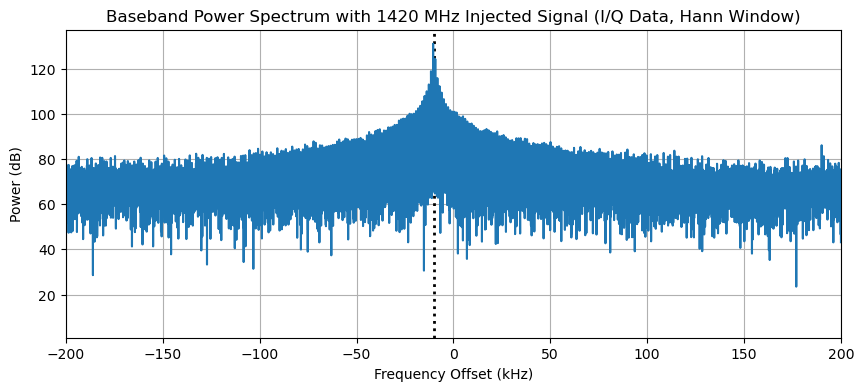

In [40]:
# PLOT 1: INJECTED SIGNAL

test = np.load("../Lab2_Data/testfreq1420_2.npz")
test_notes, indexdata = test["arr_0"], test["arr_1"]
print(test_notes)

# Data looks good. Need to use OG plotting stuff to compile and average then plot

# Moving the amplitude to zero dBm

# Plotting data 

# importdata = np.load("freq1420.npz")
# indexdata = importdata["arr_1"]
# print(importdata["arr_0"])
data = indexdata[3]

# Convert I/Q to complex data
complexdata = data[:,0] + 1j * data[:,1]

# FFT Parameters 
sampling_rate = 2.9e6
N = len(complexdata)

# Hann window + FFT
window = np.hanning(N)
fft_data = np.fft.fftshift(np.fft.fft(complexdata * window))

# Power Spectrum
power = np.abs(fft_data)**2
power_db = 10 * np.log10(power)

# Frequency axis (baseband)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1/sampling_rate))

# Plotting
plt.figure(figsize=(10, 4))
plt.axvline(-10, linestyle=":", color="black", linewidth=2) # expected signal location
plt.plot(f / 1e3, power_db)
plt.xlim(-200, 200)
# plt.xlim()
plt.xlabel("Frequency Offset (kHz)")
plt.ylabel("Power (dB)")
plt.title("Baseband Power Spectrum with 1420 MHz Injected Signal (I/Q Data, Hann Window)")
plt.grid(True)
plt.show()
